## Imports

In [1]:
import geemap
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('use_inf_as_na',True)

import datetime
import pwlf
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

#Sci-kit imports
from sklearn.linear_model import LinearRegression # Ordinary Least Squares Regression
from sklearn.metrics import mean_squared_error, r2_score

## Load data

In [2]:
# Data location
location = 'TurkeyHill1'
imageset = f'../images/images_{location}/'
modelset_1 = f'../data/harmonic_1_{location}.pkl'
modelset_2 = f'../data/harmonic_2_{location}.pkl'

In [3]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    # Sentinel-2
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    
    # Landsat
    #date = filename.name.split('_')[2] # get rid of .tif
    #date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)
        
images = xr.merge(da_list)
models_1 = pd.read_pickle(modelset_1)
models_2 = pd.read_pickle(modelset_2)

## Analysis

### Helper functions

In [4]:
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df = safe_df[safe_df['Year'] > 2018]
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    safe_df['ord_date'] = safe_df['doy'] + 365.25 * ((safe_df['Year'] - safe_df['Year'].min()))
    return safe_df

def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df

def neg_mean_summer_anom(df):
    mask = (df['doy'] >= 150) & (df['doy'] <= 250)
    return -1 * df.loc[mask, 'EVI_nrml_anom'].mean()

def process_point(latitude, longitude, year, models, metric):
    df = images.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    df = add_doy_year(df)
    df = normalize_VI(df, 'EVI')
    
    model_mask = (models['lat'] == latitude) & (models['lon'] == longitude)
    model = models.loc[model_mask, 'model'].iloc[0]
    X = create_harmonics(df['ord_date'], FREQ)
    df['EVI_nrml_pred'] = model.predict(X)
    df['EVI_nrml_anom'] = df['EVI_nrml'] - df['EVI_nrml_pred']
    
    mask = df['Year'] == year
    
    return metric(df[mask])

def create_harmonics(x, frequencies):
    df = pd.DataFrame({'x': x})
    for j in frequencies:
        sin_j = np.sin(2 * np.pi * j / 365.25 * x)
        cos_j = np.cos(2 * np.pi * j / 365.25 * x)
        
        df[f'sin_{j}'] = sin_j
        df[f'cos_{j}'] = cos_j
        
    return df

### Create map of defoliation

In [5]:
FREQ = [1, 3]

In [21]:
defol_1_stat = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_1_stat.loc[len(defol_1_stat.index)] = [y, x, process_point(y, x, 2021, models_1, neg_mean_summer_anom)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

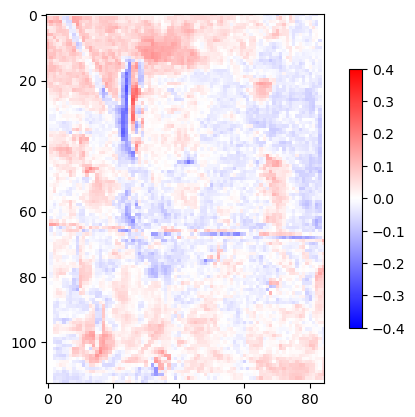

In [28]:
defol_pivot = (defol_1_stat).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot,  cmap='bwr', vmin=-0.4, vmax=0.4)
plt.colorbar(shrink = 0.7)
#plt.scatter([67], [18], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_1_nmsa', bbox_inches='tight')

In [25]:
defol_2_stat = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_2_stat.loc[len(defol_2_stat.index)] = [y, x, process_point(y, x, 2021, models_2, neg_mean_summer_anom)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

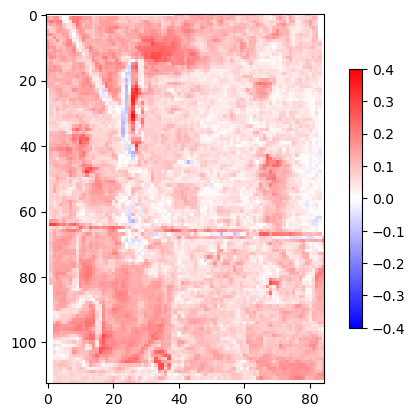

In [27]:
defol_pivot = (defol_2_stat).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot,  cmap='bwr', vmin=-0.4, vmax=0.4)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_2_nmsa', bbox_inches='tight')

## Marking quality of defoliation predictions

### Option 1: Look for consecutive values below a certain threshold (compared to predicted EVI_nrml)

In [30]:
# Parameters
THRESHOLD = -0.2         # How far below the predicted value a measurement must be to be a sign of defoliation
CONSEC = 2               # Number of consecutive observations below threshold to be declared defoliation
START, END = 150, 250    # The window for when consecutive observations must occur.

In [31]:
def evaluate_quality_thresh(latitude, longitude, year, models):
    df = images.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    df = add_doy_year(df)
    df = normalize_VI(df, 'EVI')
    
    model_mask = (models['lat'] == latitude) & (models['lon'] == longitude)
    model = models.loc[model_mask, 'model'].iloc[0]
    X = create_harmonics(df['ord_date'], FREQ)
    df['EVI_nrml_pred'] = model.predict(X)
    df['EVI_nrml_anom'] = df['EVI_nrml'] - df['EVI_nrml_pred']
    
    
    ### CHECK THIS, may not be checking consecutive we are already masking by the threshold (df['EVI_nrml_anom'] < threshold) & \
    mask = (df['Year'] == year) & \
           (df['doy'] >= START) & (df['doy'] <= END)
    
    to_check = (df[mask]).sort_values('doy')
    
    count = 0
    for i in to_check['EVI_nrml_anom']:
        if i < THRESHOLD:
            count += 1
            if count >= CONSEC:
                return 1
        else:
            count = 0
    return 0

In [32]:
# Test, should report 1
evaluate_quality_thresh(4701045.0, 383645.0, 2021, models_1)

1

In [33]:
quality_1 = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            quality_1.loc[len(quality_1.index)] = [y, x, evaluate_quality_thresh(y, x, 2021, models_1)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

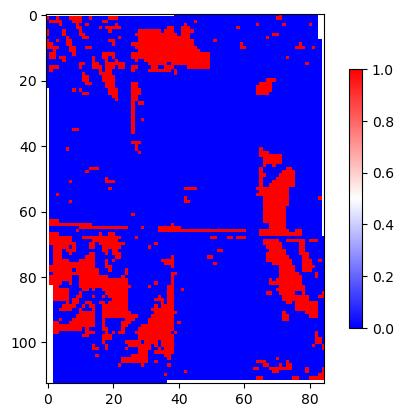

In [34]:
quality_pivot = (quality_1).pivot(index = 'lat', columns = 'lon')
plt.imshow(quality_pivot,  cmap='bwr', vmin=0, vmax=1)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_1_consec', bbox_inches='tight')

In [35]:
quality_2 = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            quality_2.loc[len(quality_2.index)] = [y, x, evaluate_quality_thresh(y, x, 2021, models_2)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

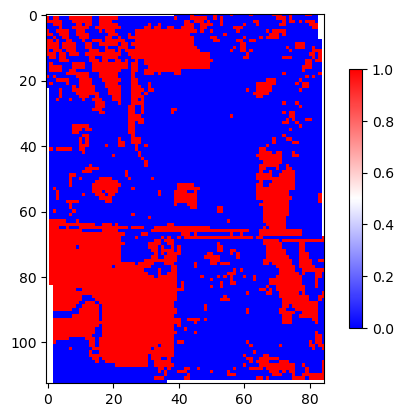

In [36]:
quality_pivot = (quality_2).pivot(index = 'lat', columns = 'lon')
plt.imshow(quality_pivot,  cmap='bwr', vmin=0, vmax=1)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_2_consec', bbox_inches='tight')

### Option 2: Window of below threshold predictions (compared to predicted EVI_nrml)

In [8]:
# Parameters
THRESHOLD = -0.1         # How far below the predicted value a measurement must be to be a sign of defoliation.
WIN_SIZE = 30            # Size of window (in days) to look for below threshold predictions, for best results use an even value.
START, END = 150, 250    # The window for when consecutive observations must occur.

In [38]:
def evaluate_quality_win(latitude, longitude, year, models):
    df = images.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    df = add_doy_year(df)
    df = normalize_VI(df, 'EVI')
    
    model_mask = (models['lat'] == latitude) & (models['lon'] == longitude)
    model = models.loc[model_mask, 'model'].iloc[0]
    X = create_harmonics(df['ord_date'], FREQ)
    df['EVI_nrml_pred'] = model.predict(X)
    df['EVI_nrml_anom'] = df['EVI_nrml'] - df['EVI_nrml_pred']
    
    for i in range(START + WIN_SIZE//2, END - WIN_SIZE//2 + 2):
        mask = (df['doy'] >= i - WIN_SIZE//2) & (df['doy'] <= i + WIN_SIZE//2 + 1) & \
               (df['Year'] == year)
        if (df.loc[mask, 'EVI_nrml_anom'] < THRESHOLD).all() & len(df[mask]) > 0:
            return 1
    return 0

In [39]:
# Test, should report 1
evaluate_quality_win(4701045.0, 383645.0, 2021, models_1)

1

In [40]:
quality_1_win = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            quality_1_win.loc[len(quality_1_win.index)] = [y, x, evaluate_quality_win(y, x, 2021, models_1)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

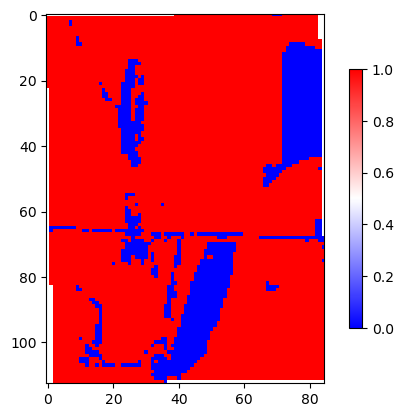

In [41]:
quality_pivot = (quality_1_win).pivot(index = 'lat', columns = 'lon')
plt.imshow(quality_pivot,  cmap='bwr', vmin=0, vmax=1)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_1_win', bbox_inches='tight')

In [ ]:
quality_2_win = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            quality_2_win.loc[len(quality_2_win.index)] = [y, x, evaluate_quality_win(y, x, 2021, models_2)]
            pbar.update(1)

In [ ]:
quality_pivot = (quality_1_win).pivot(index = 'lat', columns = 'lon')
plt.imshow(quality_pivot,  cmap='bwr', vmin=0, vmax=1)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_2_win', bbox_inches='tight')

## Alternative measure of defoliation: Integrated Anomaly
Measure anomaly based on the calculus integration of anomaly over the summer period. A naive approach defines $$\int^b_a f(x) dx = \int^b_a \hat f (x) 
dx$$ where $\hat f$ is the mean of $f(x)$, which is equivalent to the NMSA approach outlined above, but multipled by -100. An alternative is to assume $f(x)$ is locally constant, and integrate using Riemann sums where the height of each rectangle is one data point and the width of each rectangle is the interval of values that are closer to the data point than any others.

In [6]:
def integrated_anom(df):
    mask = (df['doy'] >= START) & (df['doy'] <= END)
    
    to_check = (df[mask]).sort_values('doy')
    
    total = 0
    for i in range(len(to_check) - 1):
        if i == 0:
            ran = to_check['doy'].iloc[1] - 150
        elif i == len(to_check) - 2:
            ran = 250 - to_check['doy'].iloc[len(to_check) - 2]
        else:
            ran = to_check['doy'].iloc[i + 1] - to_check['doy'].iloc[i - 1]
        
        total += ran*to_check['EVI_nrml_anom'].iloc[i]
    return total

In [18]:
defol_1_stat_int = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_1_stat_int.loc[len(defol_1_stat_int.index)] = [y, x, process_point(y, x, 2021, models_1, integrated_anom)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

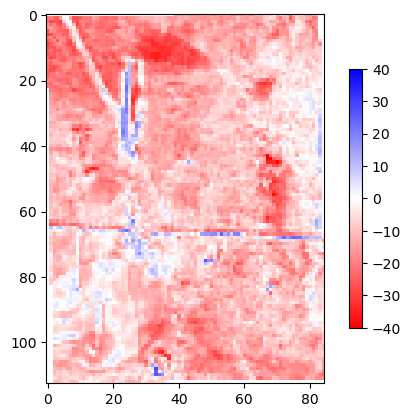

In [42]:
defol_pivot = (defol_1_stat_int).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot,  cmap='bwr_r', vmin=-40, vmax=40)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_1_intanom', bbox_inches='tight')

In [9]:
defol_2_stat_int = pd.DataFrame(columns = ['lat', 'lon', 'stat'])
x_index = images.get_index('lon')
y_index = images.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index: 
            defol_2_stat_int.loc[len(defol_2_stat_int.index)] = [y, x, process_point(y, x, 2021, models_2, integrated_anom)]
            pbar.update(1)

  0%|          | 0/9605 [00:00<?, ?it/s]

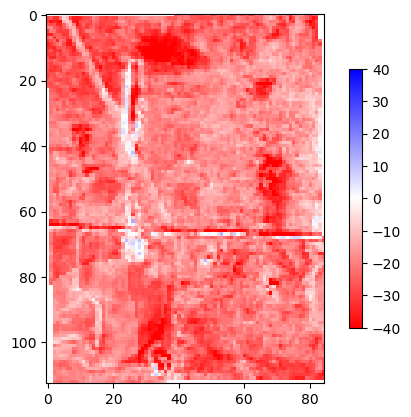

In [43]:
defol_pivot = (defol_2_stat_int).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot,  cmap='bwr_r', vmin=-40, vmax=40)
plt.colorbar(shrink = 0.7)
#plt.scatter([30], [35], color='brown')
#plt.xticks([])
#plt.yticks([])
plt.savefig(f'../data/{location}_harm_2_intanom', bbox_inches='tight')

In [14]:
defol_pivot

stat                                            \
lon          383220.000000 383230.119048 383240.238095 383250.357143   
lat                                                                    
4.700480e+06           NaN           NaN           NaN           NaN   
4.700490e+06    -28.317526    -25.976204    -32.850863    -32.975935   
4.700500e+06    -30.029031    -37.378354    -34.080865    -35.645451   
4.700510e+06    -23.855908    -28.284017    -25.986711    -33.738483   
4.700520e+06    -18.474077    -18.446760    -25.812572    -27.496554   
...                    ...           ...           ...           ...   
4.701570e+06           NaN           NaN    -19.766854    -20.823339   
4.701580e+06           NaN           NaN    -21.786389    -18.822380   
4.701590e+06           NaN           NaN    -20.932455    -19.476969   
4.701600e+06           NaN           NaN    -18.030345    -20.152570   
4.701610e+06           NaN           NaN    -21.030469    -22.551881   

                                                                      \
lon          383260.476190 383270.595238 383280.714286 383290.833333   
lat                                                                    
4.700480e+06           NaN           NaN           NaN           NaN   
4.700490e+06    -21.040462     -6.846729    -10.196440    -29.628406   
4.700500e+06    -38.045806    -11.607323     -8.034596    -12.831285   
4.700510e+06    -34.937068    -24.647196    -15.573297     -9.704101   
4.700520e+06    -31.269189    -25.917520    -18.389519    -13.478086   
...                    ...           ...           ...           ...   
4.701570e+06    -22.402420    -19.316799    -23.862233    -24.193177   
4.701580e+06    -18.503910    -15.126397    -18.472241    -19.989820   
4.701590e+06    -19.248296    -17.650292    -16.865835    -19.576666   
4.701600e+06    -21.726429    -19.722308    -19.253903    -18.753678   
4.701610e+06    -22.311428    -19.588893    -18.563426    -21.875454   

                                          ...                              \
lon          383300.952381 383311.071429  ... 383978.928571 383989.047619   
lat                                       ...                               
4.700480e+06           NaN           NaN  ...    -16.919156    -14.955822   
4.700490e+06    -35.766827    -35.959813  ...    -27.538965    -15.867219   
4.700500e+06    -35.464083    -37.643203  ...    -31.377376    -13.273105   
4.700510e+06    -19.251167    -38.113303  ...    -20.530492    -14.759565   
4.700520e+06    -12.753263    -31.070326  ...    -16.766751    -11.602876   
...                    ...           ...  ...           ...           ...   
4.701570e+06    -18.409808    -19.546797  ...    -30.107615    -29.936307   
4.701580e+06    -19.741923    -18.352353  ...    -29.835649    -28.702704   
4.701590e+06    -19.684074    -17.708165  ...    -30.380581    -30.881668   
4.701600e+06    -18.769048    -17.610134  ...    -31.945209    -35.543462   
4.701610e+06    -22.847002    -20.685355  ...           NaN           NaN   

                                                                      \
lon          383999.166667 384009.285714 384019.404762 384029.523810   
lat                                                                    
4.700480e+06    -13.843813    -16.554906    -25.132039    -27.675227   
4.700490e+06    -19.927002    -20.639056    -24.379466    -30.818767   
4.700500e+06    -16.146700    -23.117543    -34.819050    -40.219213   
4.700510e+06    -15.177105    -18.163735    -26.281301    -36.356222   
4.700520e+06    -13.381560    -16.524855    -22.827838    -27.414604   
...                    ...           ...           ...           ...   
4.701570e+06    -28.841068    -30.540186    -33.794365    -28.578051   
4.701580e+06    -27.841734    -29.175910    -33.562903    -30.569550   
4.701590e+06    -31.015320    -30.388184    -30.828013    -29.317836   
4.701600e+06    -34.419161    -35.118097    -23.725159    -26